In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Load and clean dataset

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

df = df.dropna(subset=["InvoiceNo", "StockCode", "InvoiceDate", "Quantity", "UnitPrice"])
df = df.drop_duplicates()
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

print("Cleaned Dataset Shape:", df.shape)
display(df.head())

Cleaned Dataset Shape: (524878, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Prepare customer data

In [3]:
customer_df = df.dropna(subset=["CustomerID"]).copy()
customer_df["CustomerID"] = customer_df["CustomerID"].astype(int)

print("Customers available for segmentation:", customer_df["CustomerID"].nunique())
display(customer_df.head())

Customers available for segmentation: 4338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


Calculate RFM metrics

In [4]:
reference_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = customer_df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalSales", "sum")
).reset_index()

display(rfm.head())
print("RFM Dataset Shape:", rfm.shape)

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


RFM Dataset Shape: (4338, 4)


In [5]:
display(rfm[["Recency", "Frequency", "Monetary"]].describe())

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


visualize RFM distributions

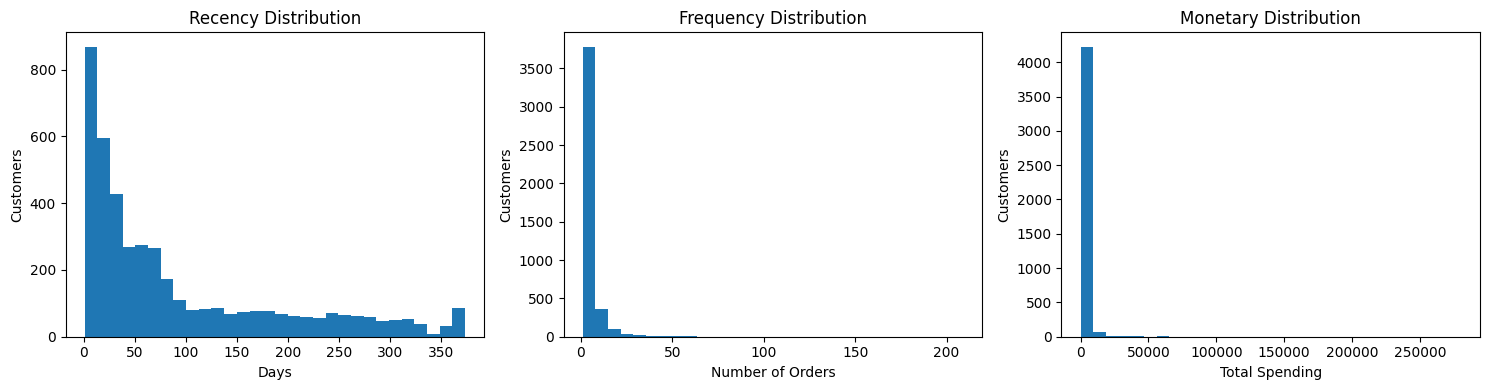

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(rfm["Recency"], bins=30)
ax[0].set_title("Recency Distribution")
ax[0].set_xlabel("Days")
ax[0].set_ylabel("Customers")

ax[1].hist(rfm["Frequency"], bins=30)
ax[1].set_title("Frequency Distribution")
ax[1].set_xlabel("Number of Orders")
ax[1].set_ylabel("Customers")

ax[2].hist(rfm["Monetary"], bins=30)
ax[2].set_title("Monetary Distribution")
ax[2].set_xlabel("Total Spending")
ax[2].set_ylabel("Customers")

plt.tight_layout()
plt.show()

Prepare data for clustering

In [7]:
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("Scaling completed.")
print("Scaled data shape:", rfm_scaled.shape)

Scaling completed.
Scaled data shape: (4338, 3)


Find optimal number of clusters

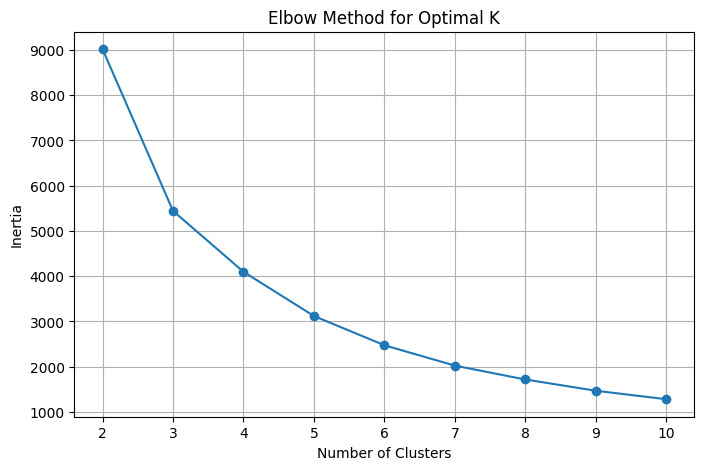

In [8]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

Silhouette score

,Clusters,Silhouette Score
0,2,0.895825
1,3,0.594223
2,4,0.616228
3,5,0.616500
4,6,0.598289
5,7,0.516532
6,8,0.485874
7,9,0.478438
8,10,0.479244


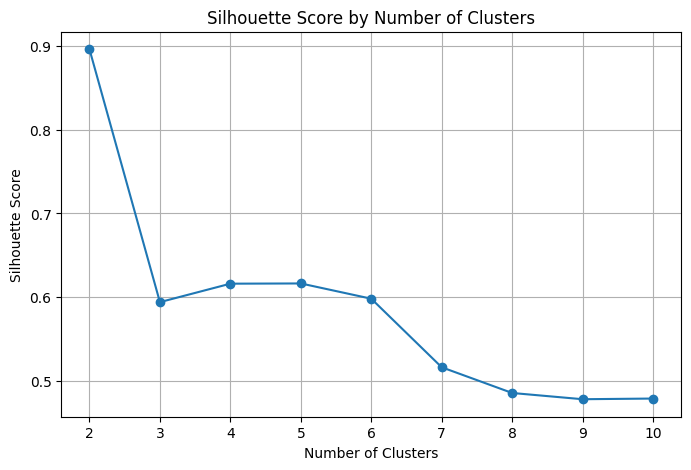

In [9]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

score_table = pd.DataFrame({
    "Clusters": range(2, 11),
    "Silhouette Score": silhouette_scores
})

display(score_table)

plt.figure(figsize=(8, 5))
plt.plot(score_table["Clusters"], score_table["Silhouette Score"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

Apply K-Means

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed.")
display(rfm.head())

K-Means clustering completed.


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,3
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,0
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,1


Analyze customer segments

In [11]:
cluster_summary = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

display(cluster_summary)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3054,43.70,3.68,1353.63
1,1067,248.08,1.55,478.85
2,13,7.38,82.54,127187.96
3,204,15.50,22.33,12690.50


Visualize customer segments

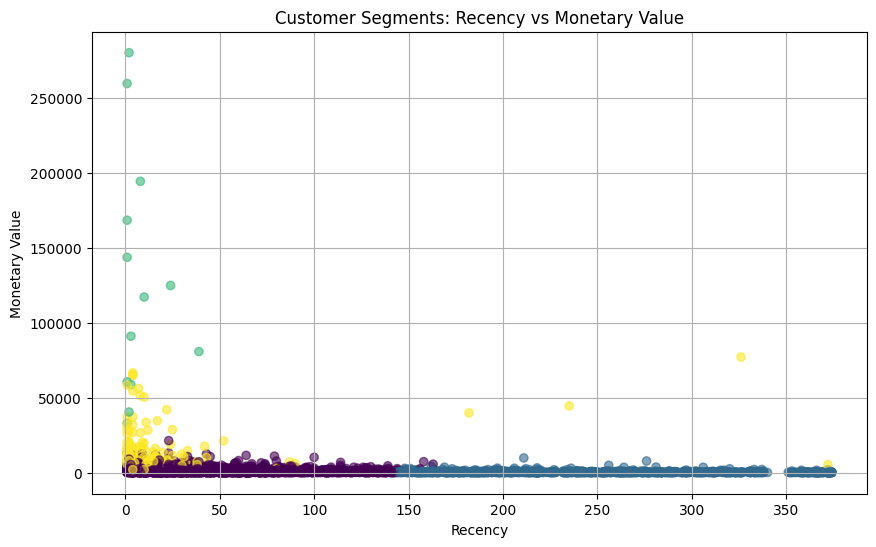

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    alpha=0.6
)

plt.title("Customer Segments: Recency vs Monetary Value")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")
plt.grid(True)
plt.show()

Frequency vs Monetary visualization

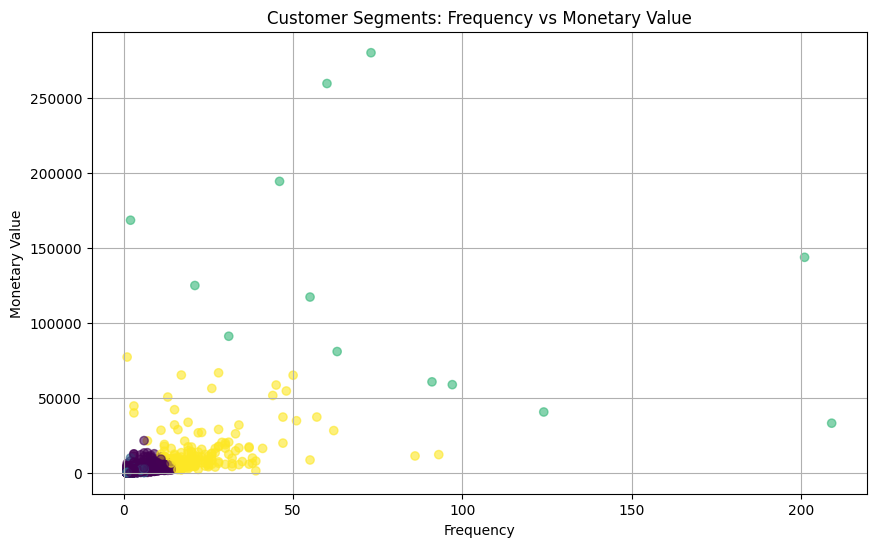

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"],
    alpha=0.6
)

plt.title("Customer Segments: Frequency vs Monetary Value")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.grid(True)
plt.show()

Identify segment characteristics

In [14]:
cluster_profile = cluster_summary.copy()

cluster_profile["Recency_Level"] = pd.cut(
    cluster_profile["Avg_Recency"],
    bins=[-np.inf, cluster_profile["Avg_Recency"].median(), np.inf],
    labels=["Low", "High"]
)

cluster_profile["Frequency_Level"] = pd.cut(
    cluster_profile["Avg_Frequency"],
    bins=[-np.inf, cluster_profile["Avg_Frequency"].median(), np.inf],
    labels=["Low", "High"]
)

cluster_profile["Monetary_Level"] = pd.cut(
    cluster_profile["Avg_Monetary"],
    bins=[-np.inf, cluster_profile["Avg_Monetary"].median(), np.inf],
    labels=["Low", "High"]
)

display(cluster_profile)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Recency_Level,Frequency_Level,Monetary_Level
Cluster,,,,,,,
0,3054,43.70,3.68,1353.63,High,Low,Low
1,1067,248.08,1.55,478.85,High,Low,Low
2,13,7.38,82.54,127187.96,Low,High,High
3,204,15.50,22.33,12690.50,Low,High,High


In [15]:
os.makedirs("week4_output", exist_ok=True)

rfm.to_csv("week4_output/customer_rfm_segments.csv", index=False)
cluster_summary.to_csv("week4_output/cluster_summary.csv")
score_table.to_csv("week4_output/silhouette_scores.csv", index=False)

print("Week 4 files saved successfully.")

Week 4 files saved successfully.


In [16]:
print("========== WEEK 4 SUMMARY ==========")
print("Total customers analyzed:", len(rfm))
print("Number of customer segments:", rfm["Cluster"].nunique())

print("\nCluster Summary:")
display(cluster_summary)

print("\nBest Silhouette Score:")
best_score = score_table.loc[score_table["Silhouette Score"].idxmax()]
print(
    f"{int(best_score['Clusters'])} clusters → "
    f"{best_score['Silhouette Score']:.3f}"
)

========== WEEK 4 SUMMARY ==========
Total customers analyzed: 4338
Number of customer segments: 4

Cluster Summary:


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3054,43.70,3.68,1353.63
1,1067,248.08,1.55,478.85
2,13,7.38,82.54,127187.96
3,204,15.50,22.33,12690.50



Best Silhouette Score:
2 clusters → 0.896
